In [3]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("/Users/AlanHDLR/Desktop")

In [5]:
data_vw = pd.read_csv("kc_house_data.csv")
data_vw

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [7]:
print(data_vw.dtypes)

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [9]:
data_vw["Intercepto"] = 1
data_vw = data_vw[["Intercepto",'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
    'floors', 'waterfront', 'view', 'condition', 'grade', 
    'yr_built', 'lat', 'long', 'price']]
print(data_vw.shape)
data_vw.head()

(21613, 14)


,Intercepto,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,yr_built,lat,long,price
0,1,3,1.00,1180,5650,1.0,0,0,3,7,1955,47.5112,-122.257,221900.0
1,1,3,2.25,2570,7242,2.0,0,0,3,7,1951,47.7210,-122.319,538000.0
2,1,2,1.00,770,10000,1.0,0,0,3,6,1933,47.7379,-122.233,180000.0
3,1,4,3.00,1960,5000,1.0,0,0,5,7,1965,47.5208,-122.393,604000.0
4,1,3,2.00,1680,8080,1.0,0,0,3,8,1987,47.6168,-122.045,510000.0


In [11]:
Xdata = data_vw[[
    'Intercepto', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
    'floors', 'waterfront', 'view', 'condition', 'grade', 'yr_built', 'lat', 'long']].values
Ydata = data_vw[["price"]].values 

In [13]:
# Dividimos en base de entrenameinto y prueba 
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size = 0.30, random_state = 1)

In [15]:
X = X_train
Y = Y_train

In [29]:
# Número de renglones en Matriz X (Base de entrenamiento)
X.shape[0]

15129

In [31]:
# Número de columnas en Matriz X (Base de entrenamiento)
X.shape[1]

13

In [33]:
# Opción de formato númerico 
np.set_printoptions(formatter = {'float_kind':'{:f}'.format})

In [35]:
# Sacara la multiplicación de X transpuesta
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[15129.000000, 50963.000000, 32017.000000, 31442387.000000,
        230231424.000000, 22665.000000, 116.000000, 3505.000000,
        51592.000000, 115894.000000, 29820815.000000, 719521.906700,
        -1848966.397000],
       [50963.000000, 184941.000000, 113274.250000, 113202849.000000,
        792701993.000000, 77591.000000, 372.000000, 12596.000000,
        174087.000000, 396101.000000, 100513486.000000, 2423751.361100,
        -6228097.770000],
       [32017.000000, 113274.250000, 76568.375000, 74367338.750000,
        529228587.750000, 51082.750000, 306.000000, 9001.500000,
        108207.500000, 254161.750000, 63280042.500000, 1522745.525575,
        -3912539.223500],
       [31442387.000000, 113202849.000000, 74367338.750000,
        77688746971.000000, 575423643809.000000, 49691571.000000,
        358581.000000, 10127227.000000, 106683065.000000,
        253007293.000000, 62104027960.000000, 1495470821.007200,
        -3842211452.765000],
       [230231424.000000, 79270

In [37]:
# Obtener la matriz inversa
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[78.213579, -0.002443, 0.015924, -0.000026, -0.000000, 0.018943,
        0.001406, 0.007214, -0.009303, 0.012217, -0.001717, -0.157461,
        0.551482],
       [-0.002443, 0.000122, -0.000040, -0.000000, 0.000000, 0.000009,
        0.000061, 0.000010, -0.000008, 0.000020, 0.000000, 0.000023,
        -0.000005],
       [0.015924, -0.000040, 0.000354, -0.000000, 0.000000, -0.000083,
        0.000005, -0.000009, -0.000015, -0.000010, -0.000002, -0.000041,
        0.000077],
       [-0.000026, -0.000000, -0.000000, 0.000000, -0.000000, 0.000000,
        -0.000000, -0.000000, 0.000000, -0.000000, 0.000000, 0.000000,
        -0.000000],
       [-0.000000, 0.000000, 0.000000, -0.000000, 0.000000, 0.000000,
        0.000000, -0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        -0.000000],
       [0.018943, 0.000009, -0.000083, 0.000000, 0.000000, 0.000360,
        -0.000059, 0.000014, 0.000032, -0.000036, -0.000002, -0.000057,
        0.000106],
       [0.001406, 0.000061, 0.000

In [39]:
# Obtener la matriz transpuesta de Y
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[8134792844.000000],
       [28921660282.000000],
       [19344041227.500000],
       [20285899254544.000000],
       [142407378785985.000000],
       [12932928855.500000],
       [186574092.000000],
       [3471948304.000000],
       [27861195467.000000],
       [66500354540.000000],
       [16042657850839.000000],
       [387121579186.851929],
       [-994165337864.434937]])

In [41]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-31174307.716793],
       [-30816.589345],
       [36233.271461],
       [172.062189],
       [-0.044589],
       [16223.767753],
       [577054.781074],
       [47766.017859],
       [26146.043330],
       [104775.597049],
       [-2546.568132],
       [564565.515986],
       [-70531.925586]])

In [43]:
# Calculo de TSS(Suma total de cudrados)
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y) * (Y.mean()**2)
TSS

array([[1900668073054776.000000]])

In [45]:
# Calculo del ESS (Suma explicada de cuadrados)
ESS = np.matmul(np.matmul(np.matrix.transpose(betas), np.matrix.transpose(X)), np.matmul(X, betas)) - len(Y) * (Y.mean()**2)
ESS

array([[1324710149391750.000000]])

In [47]:
# Calculo de RRS (Residuales al cuadrado)
RSS = TSS - ESS
RSS

array([[575957923663026.000000]])

In [49]:
# Calculo de coeficiente de determinacion R Cuadrada
RSq = 1 - RSS / TSS
RSq

array([[0.696971]])

In [51]:
# Coeficiente más adecuado para regresión multiple
# Calculo del coeficiente de Determinación R Cuadrada Ajustada
RSqAj = 1 - (RSS / (X.shape[0] - X.shape[1])) / (TSS / (X.shape[0] - 1))
RSqAj

array([[0.696730]])

In [53]:
# Reporte automatizado de la rgresión en Python
import statsmodels.api as sm

regressor = sm.OLS(Y, X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     2897.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:52:45   Log-Likelihood:            -2.0576e+05
No. Observations:               15129   AIC:                         4.115e+05
Df Residuals:                   15116   BIC:                         4.116e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.117e+07   1.73e+06    -18.058      0.0

# Quitar las variables no relevantes para ver si la presición aumenta

In [56]:
# Eliminamos la variable no relevantes
Xdata = data_vw[[
    'Intercepto', 'bedrooms', 'bathrooms', 'sqft_living', 
    'floors', 'waterfront', 'view', 'condition', 'grade', 'yr_built', 'lat', 'long']].values
Ydata = data_vw[["price"]].values 

In [58]:
# Dividimos en base de entrenameinto y prueba 
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size = 0.30, random_state = 1)

In [60]:
X = X_train
Y = Y_train

In [62]:
# Sacara la multiplicación de X transpuesta
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[15129.000000, 50963.000000, 32017.000000, 31442387.000000,
        22665.000000, 116.000000, 3505.000000, 51592.000000,
        115894.000000, 29820815.000000, 719521.906700, -1848966.397000],
       [50963.000000, 184941.000000, 113274.250000, 113202849.000000,
        77591.000000, 372.000000, 12596.000000, 174087.000000,
        396101.000000, 100513486.000000, 2423751.361100, -6228097.770000],
       [32017.000000, 113274.250000, 76568.375000, 74367338.750000,
        51082.750000, 306.000000, 9001.500000, 108207.500000,
        254161.750000, 63280042.500000, 1522745.525575, -3912539.223500],
       [31442387.000000, 113202849.000000, 74367338.750000,
        77688746971.000000, 49691571.000000, 358581.000000,
        10127227.000000, 106683065.000000, 253007293.000000,
        62104027960.000000, 1495470821.007200, -3842211452.765000],
       [22665.000000, 77591.000000, 51082.750000, 49691571.000000,
        38385.500000, 192.000000, 5408.000000, 75865.500000,
        17

In [64]:
# Obtener la matriz inversa
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[75.001408, -0.000865, 0.016521, -0.000030, 0.020293, 0.002572,
        0.006506, -0.009054, 0.012326, -0.001685, -0.149425, 0.528903],
       [-0.000865, 0.000121, -0.000040, -0.000000, 0.000008, 0.000060,
        0.000010, -0.000008, 0.000020, 0.000000, 0.000019, 0.000006],
       [0.016521, -0.000040, 0.000354, -0.000000, -0.000083, 0.000005,
        -0.000009, -0.000015, -0.000010, -0.000002, -0.000042, 0.000081],
       [-0.000030, -0.000000, -0.000000, 0.000000, 0.000000, -0.000000,
        -0.000000, 0.000000, -0.000000, 0.000000, 0.000000, -0.000000],
       [0.020293, 0.000008, -0.000083, 0.000000, 0.000360, -0.000059,
        0.000015, 0.000032, -0.000036, -0.000002, -0.000061, 0.000116],
       [0.002572, 0.000060, 0.000005, -0.000000, -0.000059, 0.010445,
        -0.000484, -0.000014, 0.000035, 0.000000, 0.000096, 0.000061],
       [0.006506, 0.000010, -0.000009, -0.000000, 0.000015, -0.000484,
        0.000153, -0.000000, -0.000016, 0.000001, 0.000044, 0.000078],
  

In [66]:
# Obtener la matriz transpuesta de Y
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[8134792844.000000],
       [28921660282.000000],
       [19344041227.500000],
       [20285899254544.000000],
       [12932928855.500000],
       [186574092.000000],
       [3471948304.000000],
       [27861195467.000000],
       [66500354540.000000],
       [16042657850839.000000],
       [387121579186.851929],
       [-994165337864.435059]])

In [68]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-31581850.548340],
       [-30616.367211],
       [36308.987003],
       [171.575712],
       [16394.993250],
       [577202.771174],
       [47676.218988],
       [26177.637057],
       [104789.403189],
       [-2542.512933],
       [565585.069189],
       [-73396.652673]])

In [70]:
# Calculo de TSS(Suma total de cudrados)
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y) * (Y.mean()**2)
TSS

array([[1900668073054776.000000]])

In [72]:
# Calculo del ESS (Suma explicada de cuadrados)
ESS = np.matmul(np.matmul(np.matrix.transpose(betas), np.matrix.transpose(X)), np.matmul(X, betas)) - len(Y) * (Y.mean()**2)
ESS

array([[1324658443416299.000000]])

In [74]:
# Calculo de RRS (Residuales al cuadrado)
RSS = TSS - ESS
RSS

array([[576009629638477.000000]])

In [76]:
# Calculo de coeficiente de determinacion R Cuadrada
RSq = 1 - RSS / TSS
RSq

array([[0.696944]])

In [140]:
# Coeficiente más adecuado para regresión multiple
# Calculo del coeficiente de Determinación R Cuadrada Ajustada
RSqAj = 1 - (RSS / (X.shape[0] - X.shape[1])) / (TSS / (X.shape[0] - 1))
RSqAj

array([[0.696723]])

In [78]:
# Reporte automatizado de la rgresión en Python
import statsmodels.api as sm

regressor = sm.OLS(Y, X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     3160.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:53:34   Log-Likelihood:            -2.0576e+05
No. Observations:               15129   AIC:                         4.115e+05
Df Residuals:                   15117   BIC:                         4.116e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.158e+07   1.69e+06    -18.682      0.0

# Como podemos ver la presición no tuvo una mejora significativa por lo que, el modelo ya es bastante precisio con o sin esta variable en concreto

In [85]:
# Aplicación sobre la base de prueba
Y_pred = np.matmul(X_test, betas)
Y_pred

array([[635229.913026],
       [432068.061296],
       [761823.654122],
       ...,
       [332832.246574],
       [2231982.874393],
       [752302.231976]])

In [87]:
# Calculo de los residuales
Resid = Y_test - Y_pred
Resid

array([[-176229.913026],
       [12931.938704],
       [295176.345878],
       ...,
       [-102832.246574],
       [-551982.874393],
       [-459302.231976]])

array([[<Axes: title={'center': '0'}>]], dtype=object)

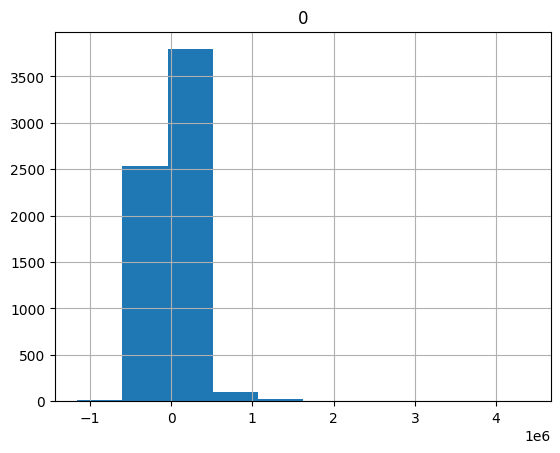

In [89]:
# Grafico del histograma de residuales para la base de prueba
df = pd.DataFrame(Resid)
df.hist()

In [91]:
from sklearn.metrics import r2_score
from sklearn import metrics

print("Coeficiente R cuadrado", r2_score(Y_test, Y_pred))

Coeficiente R cuadrado 0.6833722613131878
